# Reporting RMSDs of aligned striuctures

## AF# models

In [2]:
import mdtraj as md
import numpy as np

ref_file = "../ModMonoLigMiliNterminal.pdb"
model_atp_file = "../AF3_model/ATP_bound/fold_fadsynthase_atp_2026_04_09_model_0.cif"
model_fad_file = "../AF3_model/FAD_bound/fold_2026_04_10_08_26_model_0.cif"

ref = md.load(ref_file)
mob_atp = md.load(model_atp_file)
mob_fad = md.load(model_fad_file)


/Users/vv/miniforge3/lib/python3.12/site-packages/mdtraj/formats/pdb/pdbstructure.py:687: UserWarning: WARNING: two consecutive residues with same number (ATOM   2330  N   GLU A 301      70.754  95.656  -1.361  1.00 24.08           N  , HETATM 2329  N9  ADP A 301      52.063 103.692   3.810  1.00 23.73           N  )
  warnings.warn(


## 1) Superimpose on CA atoms and report CA RMSD after superposition

This aligns mob onto ref using protein CA atoms, then computes the CA RMSD of the aligned structures.

### CaFS/ATP

In [6]:
# Select CA atoms in each structure
ref_ca = ref.topology.select("protein and name CA")
mob_atp_ca = mob_atp.topology.select("protein and name CA")

print(f"Reference CA atoms: {len(ref_ca)}")
print(f"mob_atp   CA atoms: {len(mob_atp_ca)}")

if len(ref_ca) != len(mob_fad_ca):
    raise ValueError("Reference and mobile structures do not have the same number of CA atoms.")

# Make a copy so the original mobile structure stays unchanged
mob_atp_aligned = mob_atp[:]

# Superpose mobile onto reference using CA atoms
mob_atp_aligned.superpose(
    ref,
    atom_indices=mob_atp_ca,
    ref_atom_indices=ref_ca
)

# Compute CA RMSD after superposition
# md.rmsd returns nm, so convert to Å
rmsd_ca_nm = md.rmsd(mob_atp_aligned, ref, atom_indices=mob_atp_ca, ref_atom_indices=ref_ca)[0]
rmsd_ca_A = 10.0 * rmsd_ca_nm

print(f"CA RMSD after CA superposition: {rmsd_ca_A:.3f} Å")

Reference CA atoms: 338
mob_atp   CA atoms: 338
mob_fad   CA atoms: 338
CA RMSD after CA superposition: 1.613 Å


### CaFS/FAD

In [8]:
# Select CA atoms in each structure
ref_ca = ref.topology.select("protein and name CA")
mob_fad_ca = mob_fad.topology.select("protein and name CA")

print(f"Reference CA atoms: {len(ref_ca)}")
print(f"mob_fad   CA atoms: {len(mob_fad_ca)}")

if len(ref_ca) != len(mob_fad_ca):
    raise ValueError("Reference and mobile structures do not have the same number of CA atoms.")

# Make a copy so the original mobile structure stays unchanged
mob_fad_aligned = mob_fad[:]

# Superpose mobile onto reference using CA atoms
mob_fad_aligned.superpose(
    ref,
    atom_indices=mob_fad_ca,
    ref_atom_indices=ref_ca
)

# Compute CA RMSD after superposition
# md.rmsd returns nm, so convert to Å
rmsd_ca_nm = md.rmsd(mob_fad_aligned, ref, atom_indices=mob_fad_ca, ref_atom_indices=ref_ca)[0]
rmsd_ca_A = 10.0 * rmsd_ca_nm

print(f"CA RMSD after CA superposition: {rmsd_ca_A:.3f} Å")


Reference CA atoms: 338
mob_fad   CA atoms: 338
CA RMSD after CA superposition: 1.366 Å


## Now we compare the ligands

In [36]:
## These are the atom names of the adenine and ribose in
# ../ModMonoLigMiliNterminal.pdb

"""
HETATM 2709  C5' AMP   295      57.479 121.429  36.541  1.00 75.46           C  
HETATM 2710  O5' AMP   295      57.842 122.581  35.804  1.00 75.95           O
HETATM 2711  C4' AMP   295      56.457 121.761  37.636  1.00 73.67           C  
HETATM 2712  O4' AMP   295      56.423 120.457  38.270  1.00 73.73           O
HETATM 2713  C3' AMP   295      57.068 122.851  38.688  1.00 72.55           C  
HETATM 2714  O3' AMP   295      55.814 123.423  39.307  1.00 74.06           O
HETATM 2715  C2' AMP   295      57.848 121.893  39.634  1.00 73.14           C  
HETATM 2716  O2' AMP   295      57.890 122.307  40.956  1.00 73.80           O
HETATM 2717  C1' AMP   295      57.072 120.496  39.554  1.00 75.37           C  
HETATM 2718  N1  AMP   295      59.012 116.497  42.028  1.00 86.90           N  
HETATM 2719  C2  AMP   295      57.992 117.313  42.375  1.00 86.44           C  
HETATM 2720  N3  AMP   295      57.560 118.350  41.640  1.00 86.25           N  
HETATM 2721  C4  AMP   295      58.276 118.490  40.490  1.00 83.53           C  
HETATM 2722  C5  AMP   295      59.364 117.705  40.010  1.00 83.91           C  
HETATM 2723  C6  AMP   295      59.749 116.641  40.844  1.00 84.80           C  
HETATM 2724  N6  AMP   295      60.791 115.838  40.445  1.00 85.20           N  
HETATM 2725  N7  AMP   295      59.874 118.123  38.783  1.00 82.55           N  
HETATM 2726  C8  AMP   295      59.058 119.157  38.572  1.00 80.15           C  
HETATM 2727  N9  AMP   295      58.079 119.430  39.554  1.00 80.41           N  
"""

## These are the atom names of the adenine and ribose in
# ../AF3_model/ATP_bound/fold_fadsynthase_atp_2026_04_09_model_0.cif

"""
HETATM 2613 O "O5'" . ATP B 2 .   ? -5.980  -1.554  -11.864 1.00 93.46 1   B 1
HETATM 2614 C "C5'" . ATP B 2 .   ? -5.573  -2.883  -11.638 1.00 93.50 1   B 1
HETATM 2615 C "C4'" . ATP B 2 .   ? -6.768  -3.782  -11.737 1.00 95.08 1   B 1
HETATM 2616 O "O4'" . ATP B 2 .   ? -7.633  -3.515  -10.619 1.00 95.31 1   B 1
HETATM 2617 C "C3'" . ATP B 2 .   ? -7.627  -3.556  -12.995 1.00 93.63 1   B 1
HETATM 2618 O "O3'" . ATP B 2 .   ? -8.080  -4.815  -13.483 1.00 92.16 1   B 1
HETATM 2619 C "C2'" . ATP B 2 .   ? -8.775  -2.713  -12.497 1.00 94.63 1   B 1
HETATM 2620 O "O2'" . ATP B 2 .   ? -9.931  -2.871  -13.287 1.00 92.79 1   B 1
HETATM 2621 C "C1'" . ATP B 2 .   ? -8.952  -3.235  -11.067 1.00 95.19 1   B 1
HETATM 2622 N N9    . ATP B 2 .   ? -9.563  -2.280  -10.143 1.00 96.38 1   B 1
HETATM 2623 C C8    . ATP B 2 .   ? -9.228  -0.975  -9.948  1.00 96.32 1   B 1
HETATM 2624 N N7    . ATP B 2 .   ? -9.993  -0.420  -9.004  1.00 96.09 1   B 1
HETATM 2625 C C5    . ATP B 2 .   ? -10.843 -1.386  -8.593  1.00 96.62 1   B 1
HETATM 2626 C C6    . ATP B 2 .   ? -11.896 -1.423  -7.631  1.00 96.25 1   B 1
HETATM 2627 N N6    . ATP B 2 .   ? -12.236 -0.362  -6.900  1.00 95.82 1   B 1
HETATM 2628 N N1    . ATP B 2 .   ? -12.568 -2.594  -7.487  1.00 95.70 1   B 1
HETATM 2629 C C2    . ATP B 2 .   ? -12.252 -3.698  -8.218  1.00 95.57 1   B 1
HETATM 2630 N N3    . ATP B 2 .   ? -11.273 -3.718  -9.131  1.00 95.92 1   B 1
HETATM 2631 C C4    . ATP B 2 .   ? -10.575 -2.578  -9.315  1.00 96.74 1   B 1
```

## These are the atom names of the adenine and ribose in
## ../AF3_model/FAD_bound/fold_2026_04_10_08_26_model_0.cif

```
HETATM 2604 O O5B   . FAD B 2 .   ? 5.593   1.965   -13.522 1.00 57.00 1   B 1 
HETATM 2605 C C5B   . FAD B 2 .   ? 6.820   1.382   -13.154 1.00 58.06 1   B 1 
HETATM 2606 C C4B   . FAD B 2 .   ? 7.223   0.445   -14.265 1.00 67.49 1   B 1 
HETATM 2607 O O4B   . FAD B 2 .   ? 6.240   -0.582  -14.387 1.00 61.70 1   B 1 
HETATM 2608 C C3B   . FAD B 2 .   ? 7.325   1.153   -15.592 1.00 65.06 1   B 1 
HETATM 2609 O O3B   . FAD B 2 .   ? 8.456   0.672   -16.270 1.00 57.46 1   B 1 
HETATM 2610 C C2B   . FAD B 2 .   ? 6.025   0.746   -16.279 1.00 67.01 1   B 1 
HETATM 2611 O O2B   . FAD B 2 .   ? 6.170   0.726   -17.671 1.00 56.99 1   B 1 
HETATM 2612 C C1B   . FAD B 2 .   ? 5.754   -0.641  -15.715 1.00 64.36 1   B 1 
HETATM 2613 N N9A   . FAD B 2 .   ? 4.365   -1.048  -15.665 1.00 67.11 1   B 1 
HETATM 2614 C C8A   . FAD B 2 .   ? 3.292   -0.320  -15.287 1.00 66.56 1   B 1 
HETATM 2615 N N7A   . FAD B 2 .   ? 2.171   -1.038  -15.342 1.00 63.54 1   B 1 
HETATM 2616 C C5A   . FAD B 2 .   ? 2.528   -2.274  -15.769 1.00 65.08 1   B 1 
HETATM 2617 C C6A   . FAD B 2 .   ? 1.805   -3.489  -16.035 1.00 60.93 1   B 1 
HETATM 2618 N N6A   . FAD B 2 .   ? 0.466   -3.564  -15.877 1.00 59.38 1   B 1 
HETATM 2619 N N1A   . FAD B 2 .   ? 2.491   -4.565  -16.462 1.00 56.82 1   B 1 
HETATM 2620 C C2A   . FAD B 2 .   ? 3.837   -4.508  -16.630 1.00 60.91 1   B 1 
HETATM 2621 N N3A   . FAD B 2 .   ? 4.545   -3.398  -16.402 1.00 65.48 1   B 1 
HETATM 2622 C C4A   . FAD B 2 .   ? 3.916   -2.291  -15.973 1.00 66.76 1   B 1 
"""

# Let's make a table and put all the atom names in order...


csv_contents = """CanonicalName,HomologyName,AF3_ATP_Name,AF3_FAD_Name
N1,N1,N1,N1A
C2,C2,C2,C2A
N3,N3,N3,N3A
C4,C4,C4,C4A
C5,C5,C5,C5A
C6,C6,C6,C6A
N6,N6,N6,N6A
N7,N7,N7,N7A
C8,C8,C8,C8A
N9,N9,N9,N9A
C1',C1',"C1'",C1B
C2',C2',"C2'",C2B
O2',O2',"O2'",O2B
C3',C3',"C3'",C3B
O3',O3',"O3'",O3B
C4',C4',"C4'",C4B
O4',O4',"O4'",O4B
C5',C5',"C5'",C5B
O5',O5',"O5'",O5B
"""


import pandas as pd
import io

df = pd.read_csv(io.StringIO(csv_contents))
print(df)



   CanonicalName HomologyName AF3_ATP_Name AF3_FAD_Name
0             N1           N1           N1          N1A
1             C2           C2           C2          C2A
2             N3           N3           N3          N3A
3             C4           C4           C4          C4A
4             C5           C5           C5          C5A
5             C6           C6           C6          C6A
6             N6           N6           N6          N6A
7             N7           N7           N7          N7A
8             C8           C8           C8          C8A
9             N9           N9           N9          N9A
10           C1'          C1'          C1'          C1B
11           C2'          C2'          C2'          C2B
12           O2'          O2'          O2'          O2B
13           C3'          C3'          C3'          C3B
14           O3'          O3'          O3'          O3B
15           C4'          C4'          C4'          C4B
16           O4'          O4'          O4'      

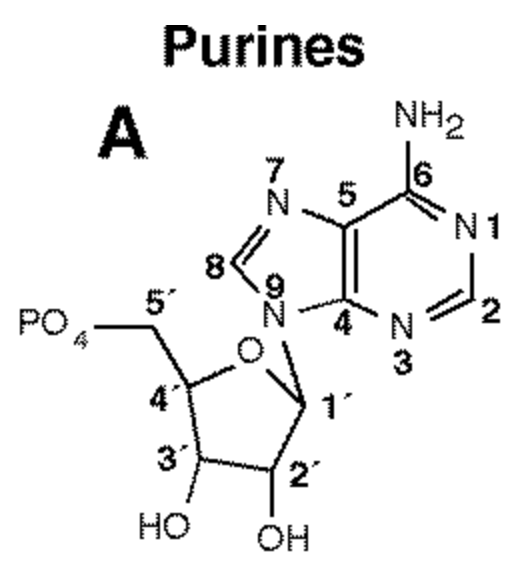

In [37]:
df['HomologyName']

0      N1
1      C2
2      N3
3      C4
4      C5
5      C6
6      N6
7      N7
8      C8
9      N9
10    C1'
11    C2'
12    O2'
13    C3'
14    O3'
15    C4'
16    O4'
17    C5'
18    O5'
Name: HomologyName, dtype: object

In [38]:
# Construct the list of atom indices for the reference
ref_lig_indices = []
for name in df['HomologyName']:
    try:
        i = ref.topology.select(f"name {name} and resname AMP")[0] 
    except:
        i = ref.topology.select(f'name "{name}" and resname AMP')[0]
    ref_lig_indices.append(int(i))

ref_lig_indices = np.array(ref_lig_indices)
ref_lig_indices

array([2640, 2641, 2642, 2643, 2644, 2645, 2646, 2647, 2648, 2649, 2639,
       2637, 2638, 2635, 2636, 2633, 2634, 2631, 2632])

In [40]:
# Construct the list of atom indices for mob_atp_aligned
mob_atp_lig_indices = []
for name in df['AF3_ATP_Name']:
    # print('name', name, end=' ')
    try:
        i = mob_atp_aligned.topology.select(f"name {name} and resname ATP")[0] 
    except:
        i = mob_atp_aligned.topology.select(f'name "{name}" and resname ATP')[0]
    mob_atp_lig_indices.append(int(i))

mob_atp_lig_indices = np.array(mob_atp_lig_indices)
mob_atp_lig_indices

array([2627, 2628, 2629, 2630, 2624, 2625, 2626, 2623, 2622, 2621, 2620,
       2618, 2619, 2616, 2617, 2614, 2615, 2613, 2612])

In [42]:
# Construct the list of atom indices for mob_fad_aligned
mob_fad_lig_indices = []
for name in df['AF3_FAD_Name']:
    # print('name', name, end=' ')
    try:
        i = mob_fad_aligned.topology.select(f"name {name} and resname FAD")[0] 
    except:
        i = mob_fad_aligned.topology.select(f'name "{name}" and resname FAD')[0]
    mob_fad_lig_indices.append(int(i))

mob_fad_lig_indices = np.array(mob_fad_lig_indices)
mob_fad_lig_indices

array([2618, 2619, 2620, 2621, 2615, 2616, 2617, 2614, 2613, 2612, 2611,
       2609, 2610, 2607, 2608, 2605, 2606, 2604, 2603])

## RMSD of adenine+ribose between Homology and ATP (AF3)

In [46]:
rmsd_lig_atp_nm = md.rmsd(mob_atp_aligned, ref, atom_indices=mob_atp_lig_indices, ref_atom_indices=ref_lig_indices)[0]
rmsd_lig_atp = 10.0 * rmsd_lig_atp_nm
print('rmsd_lig_atp', rmsd_lig_atp)

rmsd_lig_atp 0.42373698204755783


In [48]:
rmsd_lig_fad_nm = md.rmsd(mob_fad_aligned, ref, atom_indices=mob_fad_lig_indices, ref_atom_indices=ref_lig_indices)[0]
rmsd_lig_fad = 10.0 * rmsd_lig_fad_nm
print('rmsd_lig_fad', rmsd_lig_fad)

rmsd_lig_fad 0.480717271566391


# Boltz-2 models

## caFs/ATP

In [1]:
import mdtraj as md
import numpy as np

ref_file = "../ModMonoLigMiliNterminal.pdb"
model_atp_file = "../Boltz2_model/ATP_bound.pdb"
model_2ap_file = "../Boltz2_model/2AP_bound.pdb"

ref = md.load(ref_file)
mob_atp = md.load(model_atp_file)
mob_2ap = md.load(model_2ap_file)


/Users/vv/miniforge3/lib/python3.12/site-packages/mdtraj/formats/pdb/pdbstructure.py:687: UserWarning: WARNING: two consecutive residues with same number (ATOM   2330  N   GLU A 301      70.754  95.656  -1.361  1.00 24.08           N  , HETATM 2329  N9  ADP A 301      52.063 103.692   3.810  1.00 23.73           N  )
  warnings.warn(


## Superimpose on CA atoms and report CA RMSD after superposition

In [3]:
# Select CA atoms in each structure
ref_ca = ref.topology.select("protein and name CA")
mob_atp_ca = mob_atp.topology.select("protein and name CA")

print(f"Reference CA atoms: {len(ref_ca)}")
print(f"mob_atp   CA atoms: {len(mob_atp_ca)}")

if len(ref_ca) != len(mob_atp_ca):
    raise ValueError("Reference and mobile structures do not have the same number of CA atoms.")

# Make a copy so the original mobile structure stays unchanged
mob_atp_aligned = mob_atp[:]

# Superpose mobile onto reference using CA atoms
mob_atp_aligned.superpose(
    ref,
    atom_indices=mob_atp_ca,
    ref_atom_indices=ref_ca
)

# Compute CA RMSD after superposition
# md.rmsd returns nm, so convert to Å
rmsd_ca_nm = md.rmsd(mob_atp_aligned, ref, atom_indices=mob_atp_ca, ref_atom_indices=ref_ca)[0]
rmsd_ca_A = 10.0 * rmsd_ca_nm

print(f"CA RMSD after CA superposition: {rmsd_ca_A:.3f} Å")

Reference CA atoms: 338
mob_atp   CA atoms: 338
CA RMSD after CA superposition: 1.846 Å


## CaFs/2AP-TP

In [6]:
# Select CA atoms in each structure
ref_ca = ref.topology.select("protein and name CA")
mob_2ap_ca = mob_2ap.topology.select("protein and name CA")

print(f"Reference CA atoms: {len(ref_ca)}")
print(f"mob_2ap   CA atoms: {len(mob_2ap_ca)}")

if len(ref_ca) != len(mob_2ap_ca):
    raise ValueError("Reference and mobile structures do not have the same number of CA atoms.")

# Make a copy so the original mobile structure stays unchanged
mob_2ap_aligned = mob_2ap[:]

# Superpose mobile onto reference using CA atoms
mob_2ap_aligned.superpose(
    ref,
    atom_indices=mob_2ap_ca,
    ref_atom_indices=ref_ca
)

# Compute CA RMSD after superposition
# md.rmsd returns nm, so convert to Å
rmsd_ca_nm = md.rmsd(mob_2ap_aligned, ref, atom_indices=mob_2ap_ca, ref_atom_indices=ref_ca)[0]
rmsd_ca_A = 10.0 * rmsd_ca_nm

print(f"CA RMSD after CA superposition: {rmsd_ca_A:.3f} Å")


Reference CA atoms: 338
mob_2ap   CA atoms: 338
CA RMSD after CA superposition: 2.101 Å


## Now we compare the B2 ligands

In [9]:
## These are the atom names of the adenine and ribose in
# ../ModMonoLigMiliNterminal.pdb

"""
HETATM 2709  C5' AMP   295      57.479 121.429  36.541  1.00 75.46           C  
HETATM 2710  O5' AMP   295      57.842 122.581  35.804  1.00 75.95           O
HETATM 2711  C4' AMP   295      56.457 121.761  37.636  1.00 73.67           C  
HETATM 2712  O4' AMP   295      56.423 120.457  38.270  1.00 73.73           O
HETATM 2713  C3' AMP   295      57.068 122.851  38.688  1.00 72.55           C  
HETATM 2714  O3' AMP   295      55.814 123.423  39.307  1.00 74.06           O
HETATM 2715  C2' AMP   295      57.848 121.893  39.634  1.00 73.14           C  
HETATM 2716  O2' AMP   295      57.890 122.307  40.956  1.00 73.80           O
HETATM 2717  C1' AMP   295      57.072 120.496  39.554  1.00 75.37           C  
HETATM 2718  N1  AMP   295      59.012 116.497  42.028  1.00 86.90           N  
HETATM 2719  C2  AMP   295      57.992 117.313  42.375  1.00 86.44           C  
HETATM 2720  N3  AMP   295      57.560 118.350  41.640  1.00 86.25           N  
HETATM 2721  C4  AMP   295      58.276 118.490  40.490  1.00 83.53           C  
HETATM 2722  C5  AMP   295      59.364 117.705  40.010  1.00 83.91           C  
HETATM 2723  C6  AMP   295      59.749 116.641  40.844  1.00 84.80           C  
HETATM 2724  N6  AMP   295      60.791 115.838  40.445  1.00 85.20           N  
HETATM 2725  N7  AMP   295      59.874 118.123  38.783  1.00 82.55           N  
HETATM 2726  C8  AMP   295      59.058 119.157  38.572  1.00 80.15           C  
HETATM 2727  N9  AMP   295      58.079 119.430  39.554  1.00 80.41           N  
"""

## These are the atom names of the adenine and ribose in
# ../Boltz2_model/ATP_bound.pdb


"""
HETATM 2600  N38 LIG B   1      -4.993  14.806   6.653  1.00 96.32           N  
HETATM 2601  C34 LIG B   1      -4.013  15.552   6.089  1.00 96.29           C  
HETATM 2602  N20 LIG B   1      -4.326  16.598   5.308  1.00 96.07           N  
HETATM 2603  C33 LIG B   1      -3.332  17.340   4.748  1.00 95.59           C  
HETATM 2604  N22 LIG B   1      -2.013  17.103   4.928  1.00 95.98           N  
HETATM 2605  C37 LIG B   1      -1.685  16.067   5.716  1.00 96.50           C  
HETATM 2606  C36 LIG B   1      -2.653  15.241   6.326  1.00 96.67           C  
HETATM 2607  N21 LIG B   1      -2.020  14.286   7.036  1.00 96.48           N  
HETATM 2608  C35 LIG B   1      -0.719  14.499   6.891  1.00 96.19           C  
HETATM 2609  N39 LIG B   1      -0.498  15.570   6.101  1.00 96.69           N  
HETATM 2610  C43 LIG B   1       0.790  16.133   5.685  1.00 96.57           C  
HETATM 2611  O25 LIG B   1       1.448  15.189   4.847  1.00 96.37           O  
HETATM 2612  C44 LIG B   1       2.858  15.338   5.016  1.00 96.43           C  
HETATM 2613  C40 LIG B   1       3.420  13.976   5.375  1.00 96.04           C  
HETATM 2614  O30 LIG B   1       3.110  13.657   6.710  1.00 94.75           O  
HETATM 2615  P46 LIG B   1       3.141  12.128   7.237  1.00 96.53           P  
HETATM 2616  O18 LIG B   1       3.848  11.272   6.234  1.00 94.11           O  
HETATM 2617  O28 LIG B   1       3.637  12.132   8.647  1.00 91.12           O  
HETATM 2618  O32 LIG B   1       1.576  11.777   7.190  1.00 93.54           O  
HETATM 2619  P47 LIG B   1       0.540  11.179   8.274  1.00 96.02           P  
HETATM 2620  O19 LIG B   1      -0.571  10.596   7.464  1.00 89.63           O  
HETATM 2621  O29 LIG B   1       0.165  12.275   9.220  1.00 91.45           O  
HETATM 2622  O31 LIG B   1       1.318   9.998   9.050  1.00 93.01           O  
HETATM 2623  P45 LIG B   1       1.076   9.421  10.525  1.00 94.07           P  
HETATM 2624  O17 LIG B   1       1.808   8.125  10.531  1.00 79.62           O  
HETATM 2625  O26 LIG B   1      -0.411   9.250  10.749  1.00 81.00           O  
HETATM 2626  O27 LIG B   1       1.681  10.435  11.474  1.00 77.65           O  
HETATM 2627  C41 LIG B   1       3.064  16.380   6.102  1.00 95.81           C  
HETATM 2628  O23 LIG B   1       3.299  17.634   5.497  1.00 95.62           O  
HETATM 2629  C42 LIG B   1       1.747  16.383   6.833  1.00 96.06           C  
HETATM 2630  O24 LIG B   1       1.490  17.586   7.525  1.00 95.00           O  

"""

## These are the atom names of the adenine and ribose in
## ../Boltz2_model/2AP_bound.pdb

"""
HETATM 2600  N38 LIG B   1      -8.598   5.002 -14.343  1.00 94.70           N  
HETATM 2601  C33 LIG B   1      -7.263   4.962 -14.136  1.00 96.28           C  
HETATM 2602  N20 LIG B   1      -6.686   6.038 -13.541  1.00 96.16           N  
HETATM 2603  C34 LIG B   1      -5.344   6.032 -13.298  1.00 96.38           C  
HETATM 2604  C36 LIG B   1      -4.574   4.941 -13.668  1.00 96.73           C  
HETATM 2605  N21 LIG B   1      -3.279   4.636 -13.562  1.00 96.39           N  
HETATM 2606  C35 LIG B   1      -3.112   3.426 -14.107  1.00 96.19           C  
HETATM 2607  N39 LIG B   1      -4.308   2.952 -14.565  1.00 96.79           N  
HETATM 2608  C43 LIG B   1      -4.575   1.674 -15.210  1.00 96.64           C  
HETATM 2609  O25 LIG B   1      -4.395   0.651 -14.236  1.00 96.58           O  
HETATM 2610  C44 LIG B   1      -3.904  -0.524 -14.882  1.00 96.56           C  
HETATM 2611  C40 LIG B   1      -2.616  -0.923 -14.200  1.00 95.97           C  
HETATM 2612  O30 LIG B   1      -1.694   0.083 -14.460  1.00 94.55           O  
HETATM 2613  P46 LIG B   1      -0.241   0.098 -13.789  1.00 96.12           P  
HETATM 2614  O18 LIG B   1      -0.360  -0.112 -12.324  1.00 92.57           O  
HETATM 2615  O28 LIG B   1       0.664  -0.766 -14.587  1.00 87.28           O  
HETATM 2616  O32 LIG B   1       0.007   1.645 -14.044  1.00 91.31           O  
HETATM 2617  P47 LIG B   1       1.135   2.404 -14.846  1.00 89.61           P  
HETATM 2618  O19 LIG B   1       1.912   1.474 -15.693  1.00 77.66           O  
HETATM 2619  O29 LIG B   1       0.471   3.559 -15.498  1.00 85.37           O  
HETATM 2620  O31 LIG B   1       2.055   2.865 -13.609  1.00 89.01           O  
HETATM 2621  P45 LIG B   1       2.444   4.367 -13.212  1.00 93.53           P  
HETATM 2622  O17 LIG B   1       3.475   4.209 -12.146  1.00 79.61           O  
HETATM 2623  O26 LIG B   1       1.189   5.011 -12.718  1.00 79.30           O  
HETATM 2624  O27 LIG B   1       3.011   5.008 -14.472  1.00 77.51           O  
HETATM 2625  C41 LIG B   1      -3.712  -0.171 -16.340  1.00 96.04           C  
HETATM 2626  O23 LIG B   1      -4.843  -0.591 -17.082  1.00 96.09           O  
HETATM 2627  C42 LIG B   1      -3.628   1.331 -16.336  1.00 96.28           C  
HETATM 2628  O24 LIG B   1      -4.000   1.915 -17.574  1.00 95.28           O  
HETATM 2629  C37 LIG B   1      -5.244   3.867 -14.295  1.00 96.48           C  
HETATM 2630  N22 LIG B   1      -6.571   3.866 -14.525  1.00 96.70           N  
"""

# Let's make a table and put all the atom names in order...


csv_B2_contents = """CanonicalName,HomologyName,B2_ATP_Name,B2_2AP_Name
N1,N1,N20,N20
C2,C2,C33,C33
N3,N3,N22,N22
C4,C4,C37,C37
C5,C5,C36,C36
C6,C6,C34,C34
N7,N7,N21,N21
C8,C8,C35,C35
N9,N9,N39,N39
C1',C1',C43,C43
C2',C2',C42,C42
O2',O2',O24,O24
C3',C3',C41,C41
O3',O3',O23,O23
C4',C4',C44,C44
O4',O4',O25,O25
C5',C5',C40,C40
O5',O5',O30,O30
"""


import pandas as pd
import io

df = pd.read_csv(io.StringIO(csv_B2_contents))
print(df)

   CanonicalName HomologyName B2_ATP_Name B2_2AP_Name
0             N1           N1         N20         N20
1             C2           C2         C33         C33
2             N3           N3         N22         N22
3             C4           C4         C37         C37
4             C5           C5         C36         C36
5             C6           C6         C34         C34
6             N7           N7         N21         N21
7             C8           C8         C35         C35
8             N9           N9         N39         N39
9            C1'          C1'         C43         C43
10           C2'          C2'         C42         C42
11           O2'          O2'         O24         O24
12           C3'          C3'         C41         C41
13           O3'          O3'         O23         O23
14           C4'          C4'         C44         C44
15           O4'          O4'         O25         O25
16           C5'          C5'         C40         C40
17           O5'          O5

In [10]:
# Construct the list of atom indices for the reference
ref_lig_indices = []
for name in df['HomologyName']:
    try:
        i = ref.topology.select(f"name {name} and resname AMP")[0] 
    except:
        i = ref.topology.select(f'name "{name}" and resname AMP')[0]
    ref_lig_indices.append(int(i))

ref_lig_indices = np.array(ref_lig_indices)
ref_lig_indices

array([2640, 2641, 2642, 2643, 2644, 2645, 2647, 2648, 2649, 2639, 2637,
       2638, 2635, 2636, 2633, 2634, 2631, 2632])

In [12]:
# Construct the list of atom indices for mob_atp_aligned
mob_atp_lig_indices = []
for name in df['B2_ATP_Name']:
    # print('name', name, end=' ')
    try:
        i = mob_atp_aligned.topology.select(f"name {name} and resname LIG")[0] 
    except:
        i = mob_atp_aligned.topology.select(f'name "{name}" and resname LIG')[0]
    mob_atp_lig_indices.append(int(i))

mob_atp_lig_indices = np.array(mob_atp_lig_indices)
mob_atp_lig_indices

array([2601, 2602, 2603, 2604, 2605, 2600, 2606, 2607, 2608, 2609, 2628,
       2629, 2626, 2627, 2611, 2610, 2612, 2613])

In [13]:
# Construct the list of atom indices for mob_fad_aligned
mob_2ap_lig_indices = []
for name in df['B2_2AP_Name']:
    # print('name', name, end=' ')
    try:
        i = mob_2ap_aligned.topology.select(f"name {name} and resname LIG")[0] 
    except:
        i = mob_2ap_aligned.topology.select(f'name "{name}" and resname LIG')[0]
    mob_2ap_lig_indices.append(int(i))

mob_2ap_lig_indices = np.array(mob_2ap_lig_indices)
mob_2ap_lig_indices

array([2601, 2600, 2629, 2628, 2603, 2602, 2604, 2605, 2606, 2607, 2626,
       2627, 2624, 2625, 2609, 2608, 2610, 2611])

## RMSD of adenine+ribose between Homology and ATP (B2) -- excluding the amino group on adenine

In [17]:
rmsd_lig_atp_nm = md.rmsd(mob_atp_aligned, ref, atom_indices=mob_atp_lig_indices, ref_atom_indices=ref_lig_indices)[0]
rmsd_lig_atp = 10.0 * rmsd_lig_atp_nm
print('B2 rmsd_lig_atp', rmsd_lig_atp, 'Å')

B2 rmsd_lig_atp 0.4185253754258156 Å


In [16]:
rmsd_lig_2ap_nm = md.rmsd(mob_2ap_aligned, ref, atom_indices=mob_2ap_lig_indices, ref_atom_indices=ref_lig_indices)[0]
rmsd_lig_2ap = 10.0 * rmsd_lig_2ap_nm
print('B2 rmsd_lig_2ap', rmsd_lig_2ap, 'Å')

B2 rmsd_lig_2ap 0.4443061351776123 Å
